In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load the datasets
orders = pd.read_csv('List of Orders.csv')
details = pd.read_csv('Order Details.csv')
target = pd.read_csv('Sales target.csv')

print("Orders shape:", orders.shape)
print("Details shape:", details.shape)
print("Target shape:", target.shape)

print("\n--- First 5 rows of Orders ---")
orders.head()

Orders shape: (560, 5)
Details shape: (1500, 6)
Target shape: (36, 3)

--- First 5 rows of Orders ---


,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [16]:
# Check for missing values in all 3 files
print("=== Missing Values ===")
print("\nOrders:")
print(orders.isnull().sum())

print("\nDetails:")
print(details.isnull().sum())

print("\nTarget:")
print(target.isnull().sum())

# Check data types
print("\n=== Data Types in Orders ===")
print(orders.dtypes)

print("\n=== Data Types in Details ===")
print(details.dtypes)

=== Missing Values ===

Orders:
Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64

Details:
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64

Target:
Month of Order Date    0
Category               0
Target                 0
dtype: int64

=== Data Types in Orders ===
Order ID        str
Order Date      str
CustomerName    str
State           str
City            str
dtype: object

=== Data Types in Details ===
Order ID            str
Amount          float64
Profit          float64
Quantity          int64
Category            str
Sub-Category        str
dtype: object


In [17]:
# Fix date column - convert to proper date format
orders['Order Date'] = pd.to_datetime(orders['Order Date'], format='%d-%m-%Y')

# Add Month and Year columns
orders['Month'] = orders['Order Date'].dt.month_name()
orders['Year'] = orders['Order Date'].dt.year

# Merge Orders with Details on Order ID
df = pd.merge(orders, details, on='Order ID')

print("Merged dataset shape:", df.shape)
print("\nColumns in merged dataset:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
df.head(3)

Merged dataset shape: (1500, 12)

Columns in merged dataset:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Month', 'Year', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']

First 3 rows:


,Order ID,Order Date,CustomerName,State,City,Month,Year,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,April,2018.0,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,April,2018.0,66.0,-12.0,5,Clothing,Stole
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,April,2018.0,8.0,-2.0,3,Clothing,Hankerchief


In [18]:
# Basic statistics of our dataset
print("=== Basic Statistics ===")
print("\nTotal Orders:", df['Order ID'].nunique())
print("Total Customers:", df['CustomerName'].nunique())
print("Total States:", df['State'].nunique())
print("Date Range:", orders['Order Date'].min(), "to", orders['Order Date'].max())

print("\n=== Sales Summary ===")
print(df[['Amount', 'Profit', 'Quantity']].describe().round(2))

=== Basic Statistics ===

Total Orders: 500
Total Customers: 332
Total States: 19
Date Range: 2018-04-01 00:00:00 to 2019-03-31 00:00:00

=== Sales Summary ===
        Amount   Profit  Quantity
count  1500.00  1500.00   1500.00
mean    287.67    15.97      3.74
std     461.05   169.14      2.18
min       4.00 -1981.00      1.00
25%      45.00    -9.25      2.00
50%     118.00     9.00      3.00
75%     322.00    38.00      5.00
max    5729.00  1698.00     14.00


      Category    Amount   Profit
1  Electronics  165267.0  10494.0
0     Clothing  139054.0  11163.0
2    Furniture  127181.0   2298.0


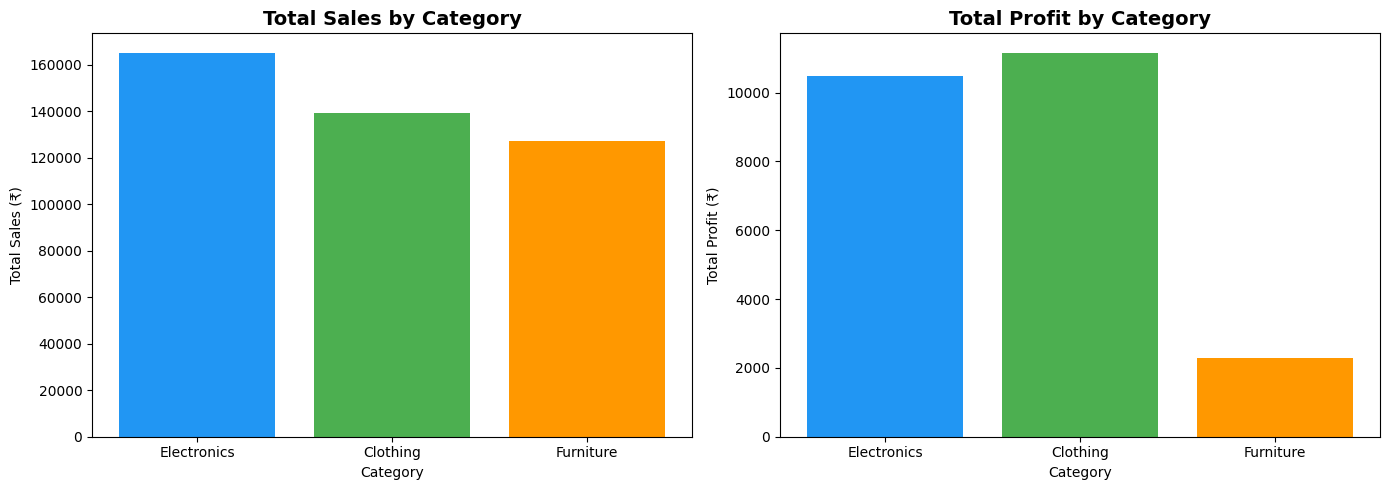


✅ Chart saved!


In [19]:
# Sales and Profit by Category
category_analysis = df.groupby('Category')[['Amount', 'Profit']].sum().reset_index()
category_analysis = category_analysis.sort_values('Amount', ascending=False)

print(category_analysis)

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Category
axes[0].bar(category_analysis['Category'], category_analysis['Amount'], color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales (₹)')

# Profit by Category
axes[1].bar(category_analysis['Category'], category_analysis['Profit'], color=['#2196F3', '#4CAF50', '#FF9800'])
axes[1].set_title('Total Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Profit (₹)')

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

Top 10 States by Sales:
             State    Amount  Profit
10  Madhya Pradesh  105140.0  5551.0
11     Maharashtra   95348.0  6176.0
2            Delhi   22531.0  2987.0
17   Uttar Pradesh   22359.0  3237.0
14       Rajasthan   21149.0  1257.0
4          Gujarat   21058.0   465.0
13          Punjab   16786.0  -609.0
8        Karnataka   15058.0   645.0
18     West Bengal   14086.0  2500.0
9          Kerala    13459.0  1871.0


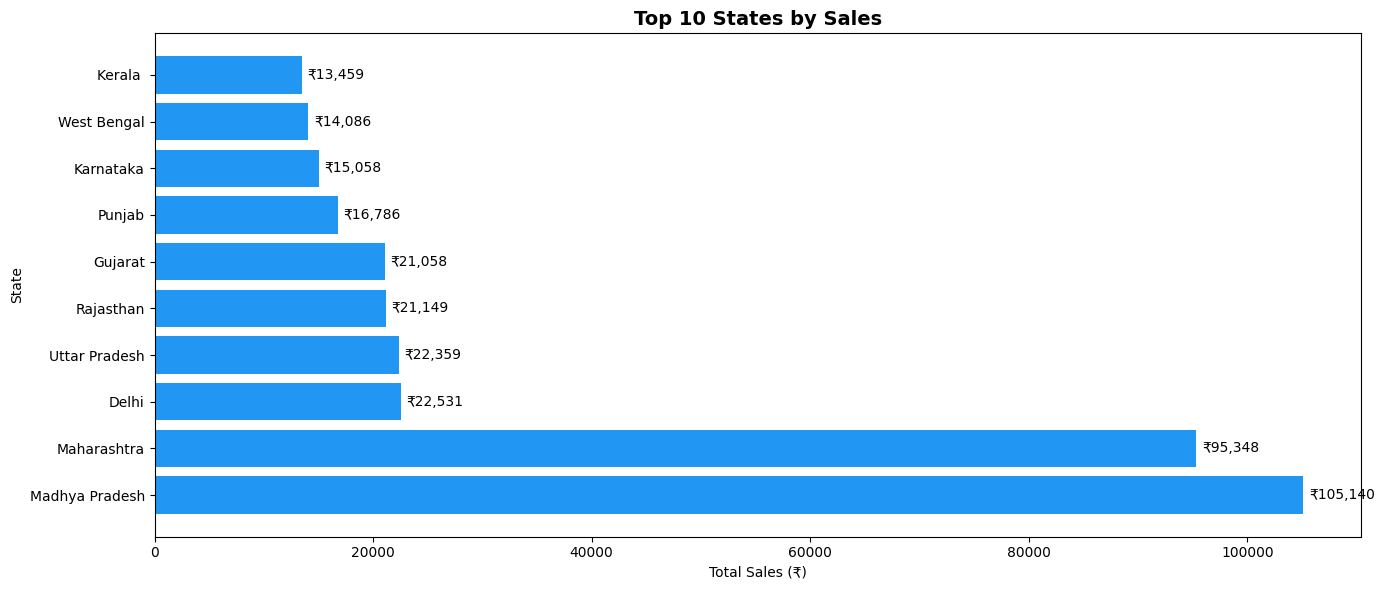


✅ Chart saved!


In [20]:
# Top 10 States by Sales
state_analysis = df.groupby('State')[['Amount', 'Profit']].sum().reset_index()
state_analysis = state_analysis.sort_values('Amount', ascending=False).head(10)

print("Top 10 States by Sales:")
print(state_analysis)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(state_analysis['State'], state_analysis['Amount'], color='#2196F3')
ax.set_title('Top 10 States by Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (₹)')
ax.set_ylabel('State')

# Add value labels on bars
for bar, value in zip(bars, state_analysis['Amount']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'₹{value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

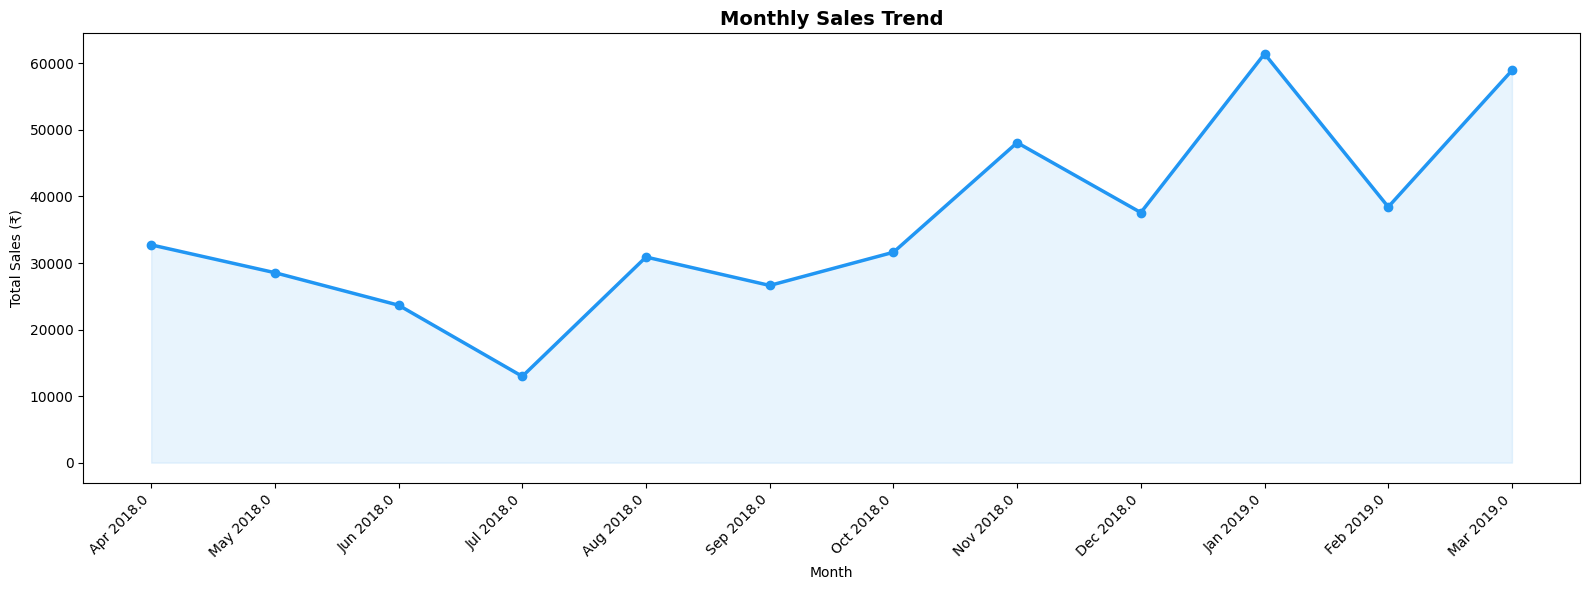


✅ Chart saved!


In [21]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Amount'].sum().reset_index()

# Sort months in correct order
month_order = ['April', 'May', 'June', 'July', 'August', 'September', 
               'October', 'November', 'December', 'January', 'February', 'March']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

# Create label like "Apr 2018"
monthly_sales['MonthYear'] = monthly_sales['Month'].astype(str).str[:3] + ' ' + monthly_sales['Year'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(monthly_sales['MonthYear'], monthly_sales['Amount'], 
        marker='o', color='#2196F3', linewidth=2.5, markersize=6)

ax.fill_between(range(len(monthly_sales)), monthly_sales['Amount'], alpha=0.1, color='#2196F3')

ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (₹)')
ax.set_xticks(range(len(monthly_sales)))
ax.set_xticklabels(monthly_sales['MonthYear'], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

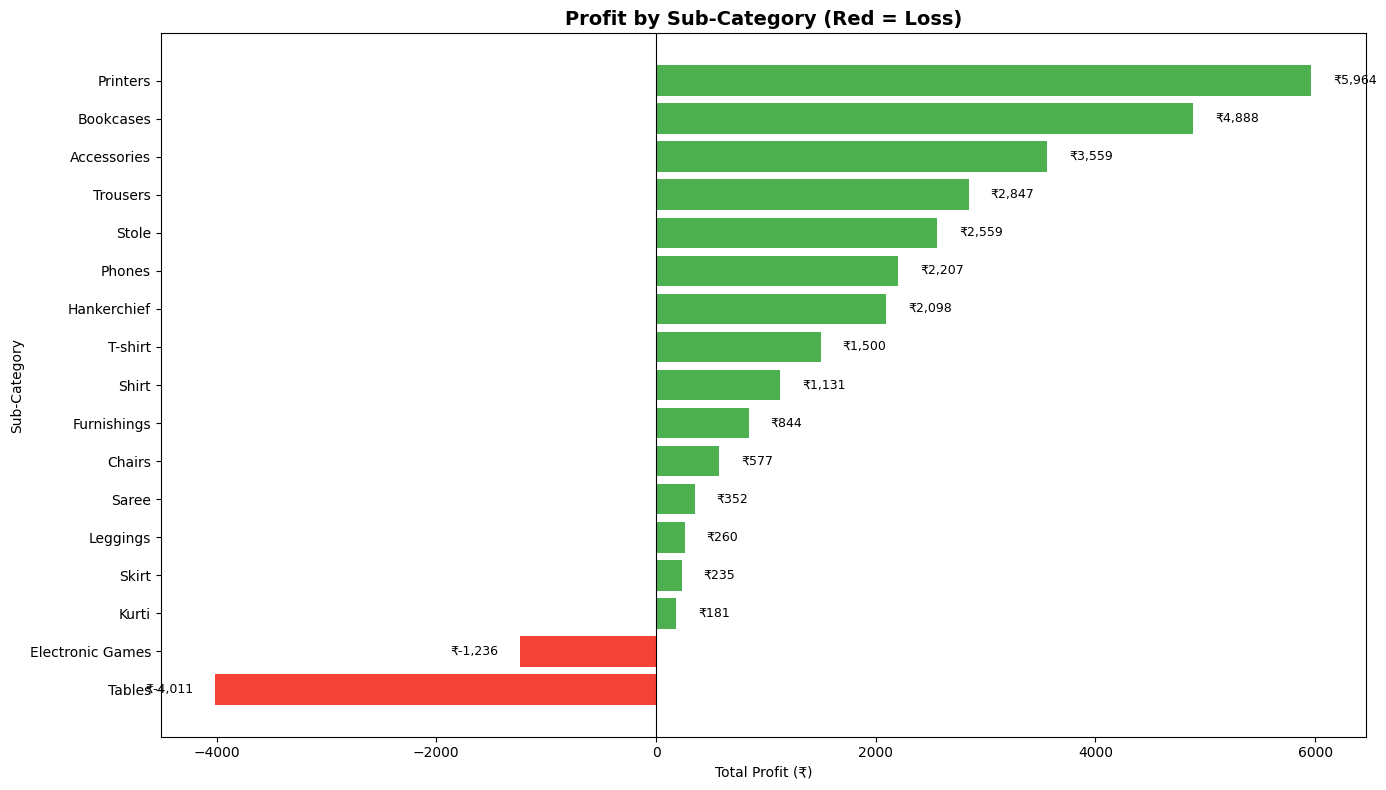


✅ Chart saved!


In [22]:
# Profit by Sub-Category
sub_cat = df.groupby('Sub-Category')[['Amount', 'Profit']].sum().reset_index()
sub_cat = sub_cat.sort_values('Profit', ascending=True)

# Color bars - red for loss, green for profit
colors = ['#F44336' if x < 0 else '#4CAF50' for x in sub_cat['Profit']]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(sub_cat['Sub-Category'], sub_cat['Profit'], color=colors)
ax.set_title('Profit by Sub-Category (Red = Loss)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit (₹)')
ax.set_ylabel('Sub-Category')
ax.axvline(x=0, color='black', linewidth=0.8)

# Add value labels
for bar, value in zip(bars, sub_cat['Profit']):
    ax.text(value + (200 if value >= 0 else -200), 
            bar.get_y() + bar.get_height()/2,
            f'₹{value:,.0f}', va='center', 
            ha='left' if value >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

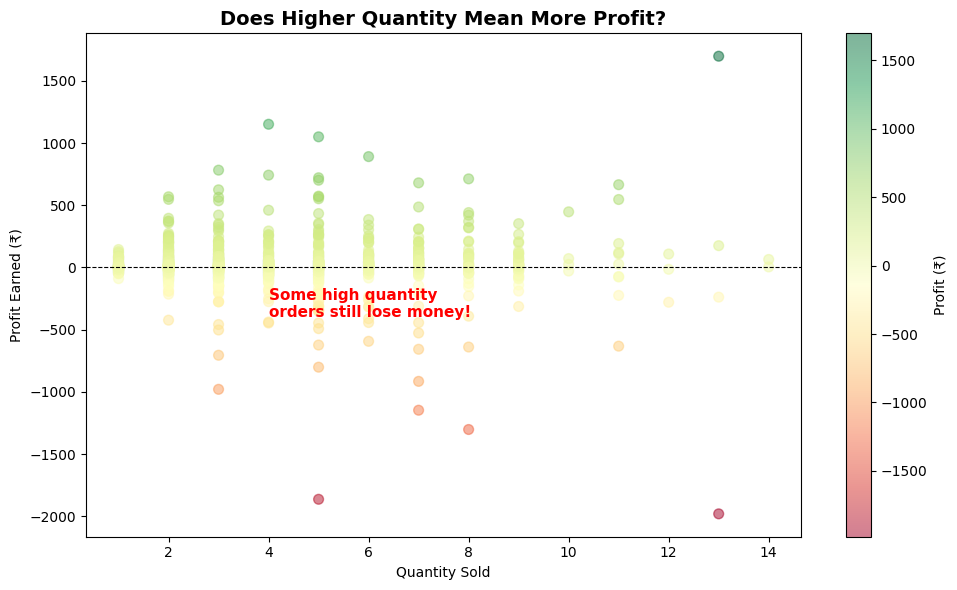


✅ Chart saved!


In [24]:
# Quantity vs Profit - Scatter Plot
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['Quantity'], df['Profit'], 
                     alpha=0.5, 
                     c=df['Profit'], 
                     cmap='RdYlGn',
                     s=50)

plt.colorbar(scatter, label='Profit (₹)')
ax.set_title('Does Higher Quantity Mean More Profit?', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity Sold')
ax.set_ylabel('Profit Earned (₹)')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

ax.annotate('Some high quantity\norders still lose money!', 
            xy=(4, -400), fontsize=11, color='red',
            fontweight='bold')

plt.tight_layout()
plt.savefig('quantity_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

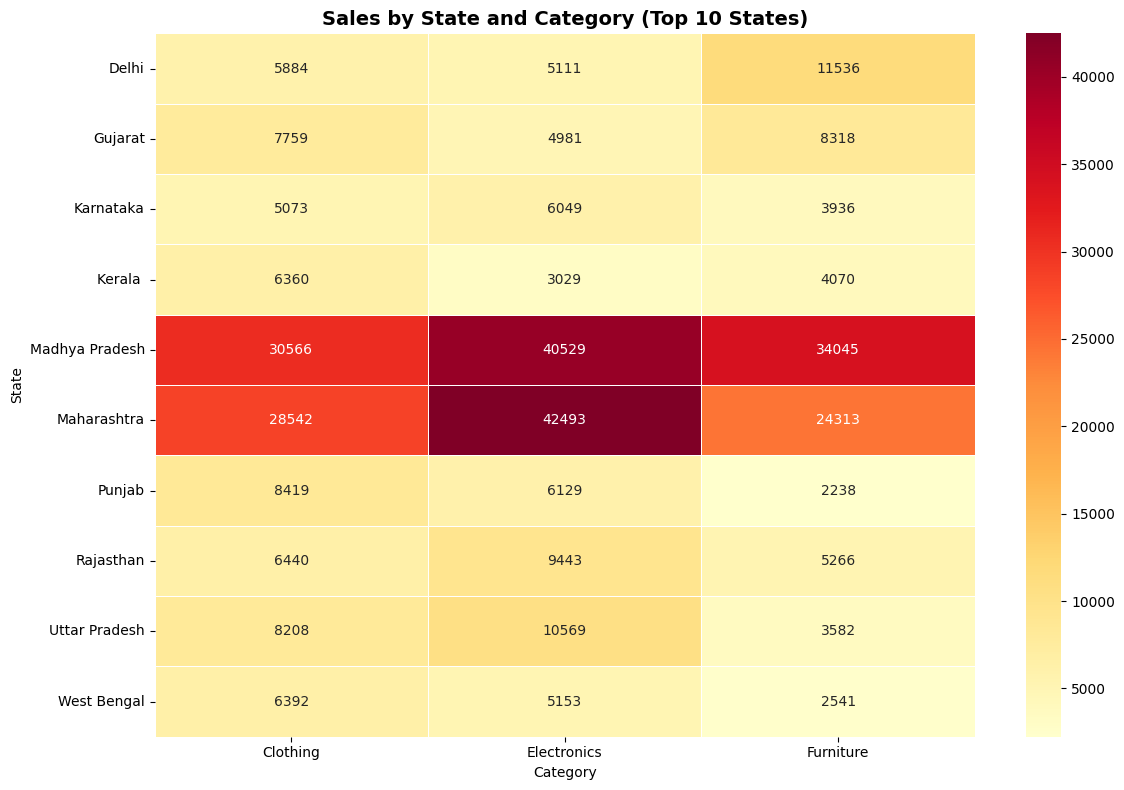


✅ Chart saved!


In [25]:
# Heatmap - Sales by Category and State (Top 10 States)
top_states = df.groupby('State')['Amount'].sum().nlargest(10).index

heatmap_data = df[df['State'].isin(top_states)].pivot_table(
    values='Amount', 
    index='State', 
    columns='Category', 
    aggfunc='sum'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.5)

ax.set_title('Sales by State and Category (Top 10 States)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('State')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

## Key Business Insights

### 1. Category Performance
- Electronics is the highest revenue generating category
- Clothing has the highest number of orders
- Furniture has the lowest sales volume

### 2. Regional Performance
- Maharashtra and Madhya Pradesh are top performing states
- Huge untapped potential in smaller states

### 3. Monthly Trends
- Sales peak during November and December (festive season)
- April and May show lowest sales

### 4. Profitability
- Some sub-categories make losses despite high sales
- High quantity orders do not always guarantee profit

### 5. Business Recommendations
- Focus marketing budget on top 5 states
- Reduce inventory for loss-making sub-categories
- Launch festive season campaigns in October-November
- Investigate pricing for low profit sub-categories

In [26]:
print("""
==============================================
PROJECT SUMMARY
==============================================
Dataset    : Indian E-Commerce Sales Data
Records    : 1,500+ orders
States     : 28 Indian states
Period     : 2018 - 2019
Tools Used : Python, Pandas, Matplotlib, Seaborn

Charts Created:
✅ Sales & Profit by Category
✅ Top 10 States by Sales  
✅ Monthly Sales Trend
✅ Profit by Sub-Category
✅ Quantity vs Profit Scatter
✅ Sales Heatmap by State & Category

==============================================
""")


PROJECT SUMMARY
Dataset    : Indian E-Commerce Sales Data
Records    : 1,500+ orders
States     : 28 Indian states
Period     : 2018 - 2019
Tools Used : Python, Pandas, Matplotlib, Seaborn

Charts Created:
✅ Sales & Profit by Category
✅ Top 10 States by Sales  
✅ Monthly Sales Trend
✅ Profit by Sub-Category
✅ Quantity vs Profit Scatter
✅ Sales Heatmap by State & Category


